# Exemplo Loja GT Auto
A loja "GT Auto" decidiu aprimorar os treinamentos de vendedores inexperientes de carros, criando uma base de dados dos veículos disponíveis que apresente algumas informações importantes para treinar os novos vendedores. A base de dados foi criada em um documento de texto e contém as seguintes informações:

*   Marca/Modelo/Ano do carro: brand/model/year
*   Capacidade volumétrica (cc) ou volume de deslocamento do motor: cap_vol.
*   Consumo de combustível (km/l): consumo.
*   Potência (cv): power.
*   Peso (kg): weight.
*   0-100 (s), tempo que o carro demora para atingir a velocidade de 100km/h: cemm. 
*   Número de cilindros: nu_cy.
*   Tipo de motor, aspirado (0) ou turbo (1): Etype.
 

Após ter realizado a análise dos dados apresentados, obter o modelo de regressão múltipla, escolha as variáveis adequadas.

In [140]:
import matplotlib.pyplot as plt
#@title Bibliotecas
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf  #adicionada na semana 6
from statsmodels.graphics.gofplots import ProbPlot

In [141]:
cars = pd.read_csv('../../data/raw/carst.csv.zip')

In [142]:
#Observar os nomes das variáveis
cars.columns

Index(['brand/model/year', 'cap_vol', 'consumo', 'power', 'weight', 'cemm',
       'nu_cy', 'Etype'],
      dtype='str')

In [143]:
#Observar o tipo de dado de cada coluna
print(cars.dtypes)

brand/model/year        str
cap_vol               int64
consumo             float64
power                 int64
weight                int64
cemm                float64
nu_cy                 int64
Etype                 int64
dtype: object


In [144]:
#Observar os índices
print(cars.index)

RangeIndex(start=0, stop=28, step=1)


In [145]:
# Reduzir a base de dados para usar apenas 
# o motor naturalmente aspirado
dfcars = cars.iloc[1:14, :]
dfcars.head(15)

,brand/model/year,cap_vol,consumo,power,weight,cemm,nu_cy,Etype
1,FIAT UNO Mille EP 1996,994,10.4,58,870,18.6,4,0
2,Hyundai HB20 Sense 2020,1000,12.8,80,989,14.5,3,0
3,FIAT Strada 1.4 2016,1368,10.3,86,1084,12.5,4,0
4,VolksWagen GOL 1.6 2015,1598,10.5,104,961,9.8,4,0
5,Chevrolet Cruze LTZ 1.8 2016,1796,8.5,144,1427,10.2,4,0
6,Honda Civic EXR 2016,1997,9.5,155,1294,10.9,4,0
7,Ford Focus 2.0 GLX 2012,1999,9.2,148,1347,10.4,4,0
8,BMW 325i 3.0 2012,2996,6.5,218,1460,7.1,6,0
9,AUDI A4 3.2 V6 Fsi 2011,3197,7.1,269,1610,6.4,6,0
10,Mercedes-Benz CLS 350 3.5 V6 2012,3498,6.6,306,1735,6.1,6,0


In [146]:
#dimensões 
print(dfcars.shape)
#número de instâncias 
na = dfcars.shape[0]
# número de variáveis
pa = dfcars.shape[1] - 1

(13, 8)


In [147]:
#@title Regressão Primeira opção
#Regressão com a fórmula import statsmodels.formula.api as smf 
regmul = smf.ols('consumo ~ cap_vol + power + weight', data=dfcars)
#Realizar o processo de modelagem
res = regmul.fit()

In [148]:
#Membros do objeto reg
print(dir(regmul))

['__class__', '__delattr__', '__dict__', '__dir__', '__doc__', '__eq__', '__format__', '__ge__', '__getattribute__', '__getstate__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__le__', '__lt__', '__module__', '__ne__', '__new__', '__reduce__', '__reduce_ex__', '__repr__', '__setattr__', '__sizeof__', '__str__', '__subclasshook__', '__weakref__', '_check_kwargs', '_data_attr', '_df_model', '_df_resid', '_fit_collinear', '_fit_ridge', '_fit_zeros', '_formula_max_endog', '_get_init_kwds', '_handle_data', '_init_keys', '_kwargs_allowed', '_setup_score_hess', '_sqrt_lasso', 'data', 'df_model', 'df_resid', 'endog', 'endog_names', 'exog', 'exog_names', 'fit', 'fit_regularized', 'formula', 'from_formula', 'get_distribution', 'hessian', 'hessian_factor', 'information', 'initialize', 'k_constant', 'loglike', 'nobs', 'normalized_cov_params', 'pinv_wexog', 'predict', 'rank', 'score', 'weights', 'wendog', 'wexog', 'wexog_singular_values', 'whiten']


In [149]:
#Membros do objeto que o processo de modelagem forneceu
print(dir(res))

['HC0_se', 'HC1_se', 'HC2_se', 'HC3_se', '_HCCM', '__class__', '__delattr__', '__dict__', '__dir__', '__doc__', '__eq__', '__format__', '__ge__', '__getattribute__', '__getstate__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__le__', '__lt__', '__module__', '__ne__', '__new__', '__reduce__', '__reduce_ex__', '__repr__', '__setattr__', '__sizeof__', '__str__', '__subclasshook__', '__weakref__', '_abat_diagonal', '_cache', '_data_attr', '_data_in_cache', '_get_robustcov_results', '_get_wald_nonlinear', '_is_nested', '_transform_predict_exog', '_use_t', '_wexog_singular_values', 'aic', 'bic', 'bse', 'centered_tss', 'compare_f_test', 'compare_lm_test', 'compare_lr_test', 'condition_number', 'conf_int', 'conf_int_el', 'cov_HC0', 'cov_HC1', 'cov_HC2', 'cov_HC3', 'cov_kwds', 'cov_params', 'cov_type', 'df_model', 'df_resid', 'eigenvals', 'el_test', 'ess', 'f_pvalue', 'f_test', 'fittedvalues', 'fvalue', 'get_influence', 'get_prediction', 'get_robustcov_results', 'info_criteria', 'i

In [150]:
#Resultado detalhado
print(res.summary())

                            OLS Regression Results                            
Dep. Variable:                consumo   R-squared:                       0.858
Model:                            OLS   Adj. R-squared:                  0.811
Method:                 Least Squares   F-statistic:                     18.17
Date:                Tue, 24 Mar 2026   Prob (F-statistic):           0.000369
Time:                        13:45:35   Log-Likelihood:                -18.408
No. Observations:                  13   AIC:                             44.82
Df Residuals:                       9   BIC:                             47.08
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     13.8973      1.640      8.475      0.0

In [151]:
#@title Cálculo do Fcrit (tabela)
import scipy.stats

F = res.fvalue
k = res.df_model  # grau do modelo
n = res.nobs  # num. amostras
dfn = k
dfd = n - (k + 1)
alpha = 0.1  #nível de confiança.
F_critico = scipy.stats.f.ppf(1 - alpha, dfn, dfd)
print("F_crit=", F_critico)  #tabela F-dist

F_crit= 2.8128629971823895


In [152]:
#@title Cálculo t_crit (tabela t-student)
from scipy.stats import t

alpha = 0.1  # significia = 5%
df = 11  # graus de liberdade
v = t.ppf(1 - alpha / 2, df)
tt = v
print(f't_crit=: {v}')

t_crit=: 1.7958848187040433


In [153]:
#@title Regressão Segunda opção
regmul2 = smf.ols('consumo ~ cap_vol + power + weight + nu_cy', data=dfcars)
#Realizar o processo de modelagem
res2 = regmul2.fit()
#Resultado detalhado
print(res2.summary())

                            OLS Regression Results                            
Dep. Variable:                consumo   R-squared:                       0.977
Model:                            OLS   Adj. R-squared:                  0.966
Method:                 Least Squares   F-statistic:                     85.91
Date:                Tue, 24 Mar 2026   Prob (F-statistic):           1.32e-06
Time:                        13:45:35   Log-Likelihood:                -6.5200
No. Observations:                  13   AIC:                             23.04
Df Residuals:                       8   BIC:                             25.86
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     22.0213      1.437     15.329      0.0

In [154]:
#@title Regressão Terceira opção
regmul3 = smf.ols('consumo ~ power + weight + nu_cy', data=dfcars)
#Realizar o processo de modelagem
res3 = regmul3.fit()
#Resultado detalhado
print(res3.summary())

                            OLS Regression Results                            
Dep. Variable:                consumo   R-squared:                       0.977
Model:                            OLS   Adj. R-squared:                  0.969
Method:                 Least Squares   F-statistic:                     124.9
Date:                Tue, 24 Mar 2026   Prob (F-statistic):           1.19e-07
Time:                        13:45:35   Log-Likelihood:                -6.7184
No. Observations:                  13   AIC:                             21.44
Df Residuals:                       9   BIC:                             23.70
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     21.9086      1.358     16.132      0.0

In [155]:
res3.params

Intercept    21.908572
power         0.020282
weight       -0.005344
nu_cy        -2.022731
dtype: float64

In [156]:
#@title Gráficos dispersão e resíduos
#Valores previstos e residuos
y_pred = list(res3.predict())
resi = list(res3.resid)
#crear instancia influence
influence = res3.get_influence()
#obter residuos standardizados
stdresid = list(influence.resid_studentized_internal)
prop = np.divide(resi, stdresid)  #e/e*

In [157]:
y = list(dfcars['consumo'])
dftab = pd.DataFrame(list(zip(y, y_pred, resi, stdresid, prop)),
                     columns=["y", "y_p", "e", "e*", "e/e*"])
dftab.head(10)

,y,y_p,e,e*,e/e*
0,10.4,10.345134,0.054866,0.140443,0.390663
1,12.8,12.178190,0.621810,1.617789,0.384358
2,10.3,9.769516,0.530484,1.217066,0.435871
3,10.5,10.791847,-0.291847,-0.675226,0.432221
4,8.5,9.113044,-0.613044,-1.359483,0.450939
5,9.5,10.046835,-0.546835,-1.228797,0.445017
6,9.2,9.621654,-0.421654,-0.927807,0.454463
7,6.5,6.392115,0.107885,0.272351,0.396125
8,7.1,6.624970,0.475030,1.067406,0.445033
9,6.6,6.707464,-0.107464,-0.252444,0.425695


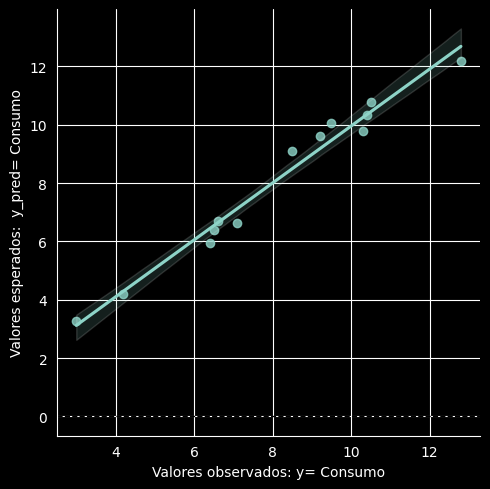

In [158]:
#@title Gráficos de diagnóstico 2 (y vs. yc)
sns.lmplot(x='y', y='y_p', data=dftab);
plt.grid(True)
plt.xlabel('Valores observados: y= Consumo')
plt.ylabel('Valores esperados:  y_pred= Consumo')
plt.axhline(y=0, color='black', linestyle='--', linewidth=1)
plt.show()

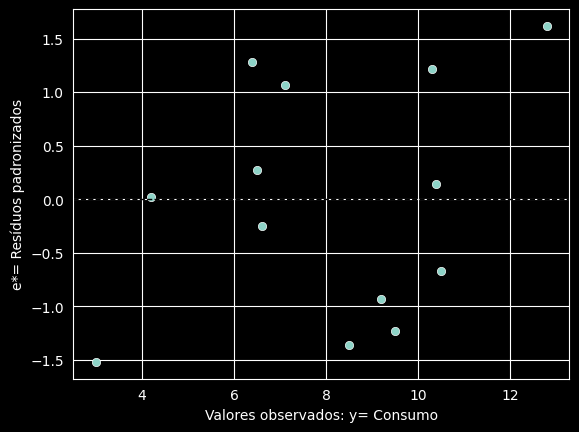

In [159]:
#@title Gráficos de diagnóstico 3 (resíduos padronizados vs. x)
sns.scatterplot(x='y', y='e*', data=dftab);
plt.grid(True)
plt.xlabel('Valores observados: y= Consumo')
plt.ylabel('e*= Resíduos padronizados')
plt.axhline(y=0, color='black', linestyle='--', linewidth=1)
plt.show()

/home/thomas/Development/Git/statistical-inference-modeling/.venv/lib/python3.12/site-packages/statsmodels/graphics/gofplots.py:1041: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "b" (-> color=(0.0, 0.0, 1.0, 1)). The keyword argument will take precedence.
  ax.plot(x, y, fmt, **plot_style)


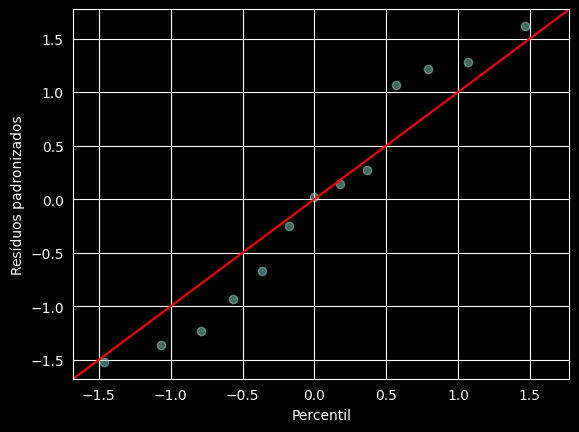

In [160]:
#@title Gráficos de diagnóstico 4
#Verificar a normalidade dos resíduos
#qqpolot vs. normal distribution 
QQ = ProbPlot(influence.resid_studentized_internal)
plot_lm_2 = QQ.qqplot(line='45', alpha=0.5, color='#4C72B0', lw=1)
plot_lm_2.axes[0].set_xlabel('Percentil')
plot_lm_2.axes[0].set_ylabel('Resíduos padronizados')
plt.grid(True)

In [161]:
#Jarque-Bera normality test import statsmodels.api as sm 
JB, JBpv, skw, kurt = sm.stats.stattools.jarque_bera(res3.resid)
print(JB, JBpv, skw, kurt)

0.935600419555486 0.6263786554878787 0.08916068550630372 1.6979002335974034


In [162]:
#Analisar amostras influentes
infl = res3.get_influence()
#leverage 
print(infl.hat_matrix_diag)

[0.35806038 0.37861409 0.20088976 0.21422029 0.14468658 0.16700463
 0.13126423 0.33998544 0.16694511 0.23776741 0.32914283 0.46714838
 0.86427087]


In [163]:
#Valores dos resíduos (influencias internas)
#residus = res3.resid.as_matrix() #residuals
leviers = infl.hat_matrix_diag  #leverage
sigma_err = np.sqrt(res3.scale)  #regression standard error
res_stds = stdresid / (sigma_err * np.sqrt(1.0 - leviers))
print(res_stds)

[ 0.35949995  4.20906954  2.79225934 -1.5622264  -3.01478277 -2.7612392
 -2.04154318  0.68753833  2.39848859 -0.59301501  0.05304166  3.59442848
 -8.46147643]


In [164]:
#Limiar 
#threshold leverage
seuil_levier = 2 * (pa + 1) / na
print(seuil_levier)
#identification
atyp_levier = leviers > seuil_levier
print(atyp_levier)

1.2307692307692308
[False False False False False False False False False False False False
 False]


In [165]:
#Quais carros ultrapassam esse limiar
print(dfcars.index[atyp_levier], leviers[atyp_levier])

RangeIndex(start=0, stop=0, step=1) []


In [166]:
#dimensões 
print(dfcars.shape)
#número de instâncias 
na = dfcars.shape[0]
# número de variáveis
pa = dfcars.shape[1] - 4
na, pa

(13, 8)


(13, 4)

In [167]:
#valores fornecidos pelo objeto
print(infl.resid_studentized_external)
#verificando com a fórmula
res_studs = res_stds * np.sqrt((na - pa - 2) / (na - pa - 1 - res_stds ** 2))
print(res_studs)

[ 0.13255651  1.81118385  1.25541191 -0.65337419 -1.43784066 -1.26993869
 -0.91983983  0.25783951  1.07682554 -0.23885329  0.01997201  1.33351375
 -1.66218952]
[  0.33903109          nan  16.38510156  -1.75298067          nan
 -11.92105002  -2.75923754   0.66301992   4.23312159  -0.56732419
   0.04962466          nan          nan]


/tmp/ipykernel_17100/1977655639.py:4: RuntimeWarning: invalid value encountered in sqrt
  res_studs = res_stds * np.sqrt((na - pa - 2) / (na - pa - 1 - res_stds ** 2))


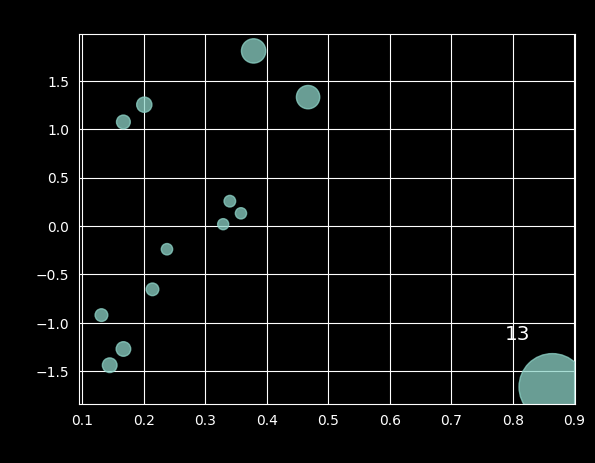

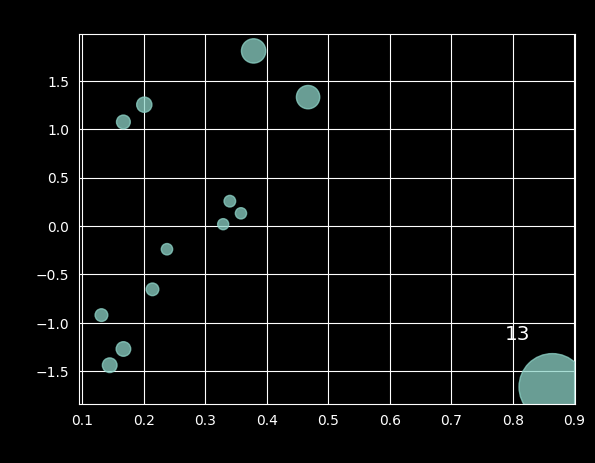

In [168]:
#Representação dos pontos influentes
sm.graphics.influence_plot(res3)

In [169]:
#limiares dos resíduos (influencias externas)
import scipy

seuil_stud = scipy.stats.t.ppf(0.975, df=na - pa - 2)
print(seuil_stud)
#detection - absolute value > threshold
atyp_stud = np.abs(res_studs) > seuil_stud
#which ones?
print(dfcars.index[atyp_stud], res_studs[atyp_stud])

2.364624251592784
Index([3, 6, 7, 9], dtype='int64') [ 16.38510156 -11.92105002  -2.75923754   4.23312159]


In [170]:
#Observações suspeitas considerando ambos critérios
pbm_infl = np.logical_or(atyp_levier, atyp_stud)
print(dfcars.index[pbm_infl])

Index([3, 6, 7, 9], dtype='int64')


In [171]:
#Outros critérios para determinar amostras influentes
print(infl.summary_frame().filter(["hat_diag", "student_resid", "dffits", "cooks_d"]))

    hat_diag  student_resid    dffits   cooks_d
1   0.358060       0.132557  0.098999  0.002750
2   0.378614       1.811184  1.413775  0.398675
3   0.200890       1.255412  0.629451  0.093093
4   0.214220      -0.653374 -0.341147  0.031074
5   0.144687      -1.437841 -0.591374  0.078161
6   0.167005      -1.269939 -0.568625  0.075681
7   0.131264      -0.919840 -0.357554  0.032517
8   0.339985       0.257840  0.185056  0.009552
9   0.166945       1.076826  0.482054  0.057082
10  0.237767      -0.238853 -0.133402  0.004970
11  0.329143       0.019972  0.013989  0.000055
12  0.467148       1.333514  1.248596  0.358727
13  0.864271      -1.662190 -4.194391  3.677834


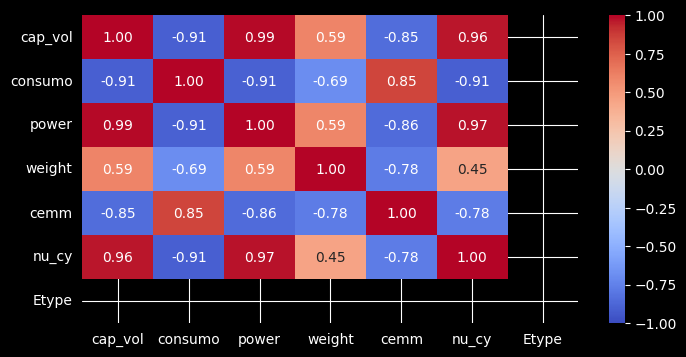

In [172]:
# Calcula a correlação entre os atributos numéricos
corr = dfcars.corr(numeric_only=True)
# Resultado
plt.figure(figsize=(8, 4))
sns.heatmap(corr, cmap='coolwarm', annot=True, fmt=".2f", vmin=-1, vmax=1)
plt.show()

In [173]:
infl.exog[:, 1:4]

array([[  58.,  870.,    4.],
       [  80.,  989.,    3.],
       [  86., 1084.,    4.],
       [ 104.,  961.,    4.],
       [ 144., 1427.,    4.],
       [ 155., 1294.,    4.],
       [ 148., 1347.,    4.],
       [ 218., 1460.,    6.],
       [ 269., 1610.,    6.],
       [ 306., 1735.,    6.],
       [ 388., 1760.,    8.],
       [ 461., 1709.,    8.],
       [ 602., 1230.,   12.]])

In [174]:
#correlation matrix 
import numpy as np

mc = np.corrcoef(infl.exog[:, 1:4], rowvar=0)
print(mc)

[[1.         0.59225355 0.96890823]
 [0.59225355 1.         0.44569531]
 [0.96890823 0.44569531 1.        ]]


In [175]:
#Klein’s rule of thumb 
mc2 = mc ** 2
print(mc2)

[[1.         0.35076427 0.93878317]
 [0.35076427 1.         0.19864431]
 [0.93878317 0.19864431 1.        ]]


In [176]:
#VIF criterion 
vif = np.linalg.inv(mc)
print(vif)

[[ 34.35864218  -6.87792632 -30.22491181]
 [ -6.87792632   2.62471127   5.49425794]
 [-30.22491181   5.49425794  27.83640092]]


## Extras

In [177]:
#ANOVA
table = sm.stats.anova_lm(res, typ=2)  #
print(table)

             sum_sq   df         F    PR(>F)
cap_vol    0.249945  1.0  0.174047  0.686315
power      0.205274  1.0  0.142941  0.714138
weight     3.079927  1.0  2.144682  0.177102
Residual  12.924689  9.0       NaN       NaN


In [178]:
#estimated coefficients 
print(res.params)
#R2
print(res.rsquared)
#calculating the F-statistic 
F = res.mse_model / res.mse_resid
print(F)
#F provided by the res object 
print(res.fvalue)

Intercept    13.897284
cap_vol      -0.000544
power        -0.006088
weight       -0.002053
dtype: float64
0.8583177713910948
18.174144629536396
18.174144629536396


### Analisando todas as variáveis do modelo final

In [179]:
dfex = dfcars.drop(columns=["Etype",  # nome
                            "cemm",  # nome
                            "cap_vol"])  # nome
dfex.head()

,brand/model/year,consumo,power,weight,nu_cy
1,FIAT UNO Mille EP 1996,10.4,58,870,4
2,Hyundai HB20 Sense 2020,12.8,80,989,3
3,FIAT Strada 1.4 2016,10.3,86,1084,4
4,VolksWagen GOL 1.6 2015,10.5,104,961,4
5,Chevrolet Cruze LTZ 1.8 2016,8.5,144,1427,4


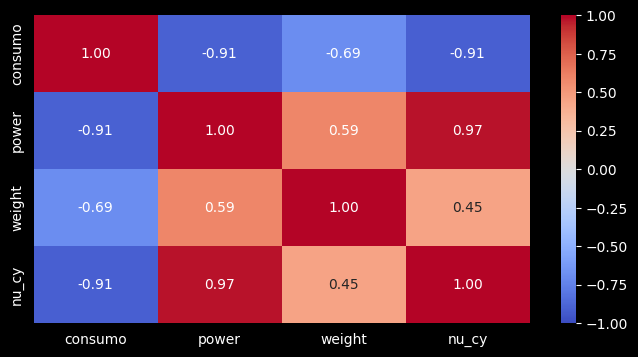

In [180]:
# Calcula a correlação entre os atributos numéricos
corr = dfex.corr(numeric_only=True)
# Resultado
plt.figure(figsize=(8, 4))
sns.heatmap(corr, cmap='coolwarm', annot=True, fmt=".2f", vmin=-1, vmax=1)
plt.show()

In [181]:
print(corr)

          consumo     power    weight     nu_cy
consumo  1.000000 -0.905766 -0.687542 -0.913702
power   -0.905766  1.000000  0.592254  0.968908
weight  -0.687542  0.592254  1.000000  0.445695
nu_cy   -0.913702  0.968908  0.445695  1.000000


In [182]:
#Klein’s rule of thumb 
mc2 = corr ** 2
print(mc2)

          consumo     power    weight     nu_cy
consumo  1.000000  0.820412  0.472714  0.834851
power    0.820412  1.000000  0.350764  0.938783
weight   0.472714  0.350764  1.000000  0.198644
nu_cy    0.834851  0.938783  0.198644  1.000000


<Axes: >

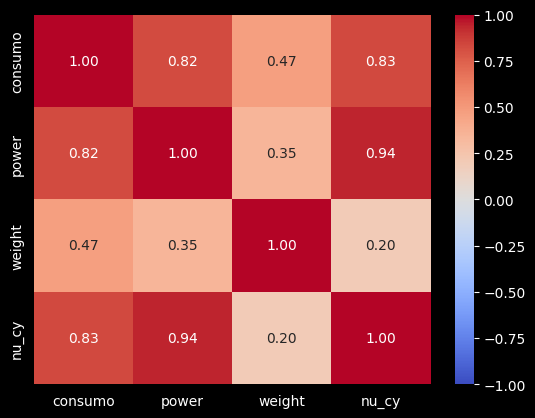

In [183]:
sns.heatmap(mc2, cmap='coolwarm', annot=True, fmt=".2f", vmin=-1, vmax=1)

In [184]:
#VIF criterion 
vif = np.linalg.inv(mc2)
print(vif)

[[  4.94510596   0.86342415  -1.727545    -4.59582941]
 [  0.86342415  11.18956754  -2.18959009 -10.79045883]
 [ -1.727545    -2.18959009   1.96748437   3.10696401]
 [ -4.59582941 -10.79045883   3.10696401  14.34955472]]


<Axes: >

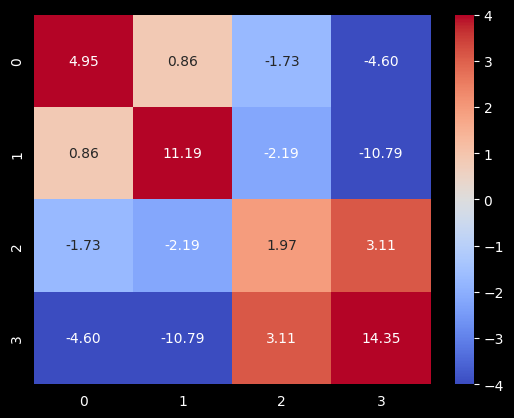

In [185]:
sns.heatmap(vif, cmap='coolwarm', annot=True, fmt=".2f", vmin=-4, vmax=4)

### Analisando apenas as variáveis preditoras do modelo final

In [186]:
dfex1 = dfcars.drop(columns=["Etype",  # nome
                             "cemm",  # nome
                             "consumo",  # nome
                             "cap_vol"])  # nome
dfex1.head()

,brand/model/year,power,weight,nu_cy
1,FIAT UNO Mille EP 1996,58,870,4
2,Hyundai HB20 Sense 2020,80,989,3
3,FIAT Strada 1.4 2016,86,1084,4
4,VolksWagen GOL 1.6 2015,104,961,4
5,Chevrolet Cruze LTZ 1.8 2016,144,1427,4


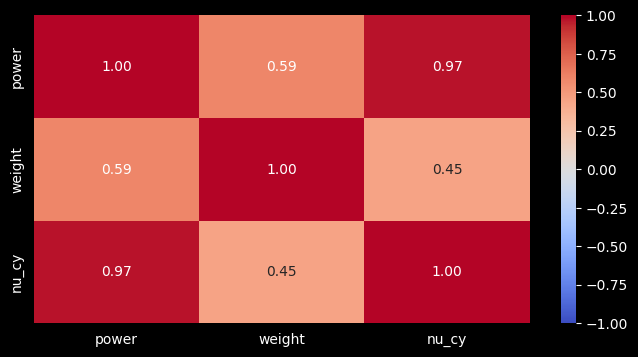

In [187]:
# Calcula a correlação entre os atributos numéricos
corr1 = dfex1.corr(numeric_only=True)
# Resultado
plt.figure(figsize=(8, 4))
sns.heatmap(corr1, cmap='coolwarm', annot=True, fmt=".2f", vmin=-1, vmax=1)
plt.show()

In [188]:
print(corr1)

           power    weight     nu_cy
power   1.000000  0.592254  0.968908
weight  0.592254  1.000000  0.445695
nu_cy   0.968908  0.445695  1.000000


In [189]:
#Klein’s rule of thumb 
mc21 = corr1 ** 2
print(mc21)

           power    weight     nu_cy
power   1.000000  0.350764  0.938783
weight  0.350764  1.000000  0.198644
nu_cy   0.938783  0.198644  1.000000


<Axes: >

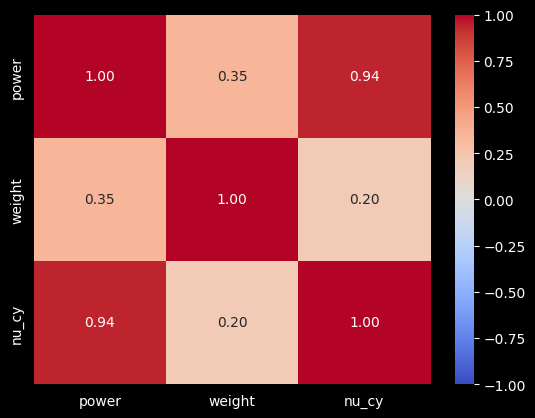

In [190]:
sns.heatmap(mc21, cmap='coolwarm', annot=True, fmt=".2f", vmin=-1, vmax=1)

In [191]:
#VIF criterion 
vif1 = np.linalg.inv(mc21)
print(vif1)

[[11.03881217 -1.88795771 -9.98801898]
 [-1.88795771  1.36397622  1.5014368 ]
 [-9.98801898  1.5014368  10.07833219]]


<Axes: >

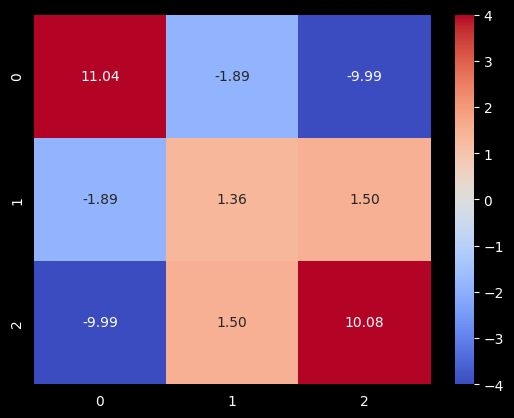

In [192]:
sns.heatmap(vif1, cmap='coolwarm', annot=True, fmt=".2f", vmin=-4, vmax=4)